STEP 1 — Import libraries & load the dataset

In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Step 2: Define column names based on dataset documentation
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]


In [4]:
# Step 3: Load dataset
df = pd.read_csv("processed.cleveland.data", header=None, names=columns)


In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [15]:
# Step 4: Replace missing '?' with NaN then convert all columns to numeric
df = df.replace("?", np.nan)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [16]:
# Step 5: Check dataset
print(df.head())
print(df.info())
print(df.isnull().sum())


    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303

STEP 2 — Data Cleaning & Preprocessing

In [17]:
# Check how many missing values each column has
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [18]:
# Impute missing values with median for numeric columns
df = df.fillna(df.median())


In [19]:
# Convert target to binary classification
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)


In [20]:
# Categorical features
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Numerical features
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [21]:
# One-hot encode categorical variables
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


In [23]:
print(df.head())
print(df.info())


        age  trestbps      chol   thalach   oldpeak  target  sex_1.0  cp_2.0  \
0  0.948726  0.757525 -0.264900  0.017197  1.087338       0     True   False   
1  1.392002  1.611220  0.760415 -1.821905  0.397182       1     True   False   
2  1.392002 -0.665300 -0.342283 -0.902354  1.346147       1     True   False   
3 -1.932564 -0.096170  0.063974  1.637359  2.122573       0     True   False   
4 -1.489288 -0.096170 -0.825922  0.980537  0.310912       0    False    True   

   cp_3.0  cp_4.0  ...  restecg_1.0  restecg_2.0  exang_1.0  slope_2.0  \
0   False   False  ...        False         True      False      False   
1   False    True  ...        False         True       True       True   
2   False    True  ...        False         True       True       True   
3    True   False  ...        False        False      False      False   
4   False   False  ...        False         True      False      False   

   slope_3.0  ca_1.0  ca_2.0  ca_3.0  thal_6.0  thal_7.0  
0       True   

STEP 3 — Exploratory Data Analysis (EDA)

In [24]:
# Summary statistics for numerical data
df.describe()


,age,trestbps,chol,thalach,oldpeak,target
count,3.030000e+02,3.030000e+02,3.030000e+02,3.030000e+02,3.030000e+02,303.000000
mean,-1.465641e-18,4.426236e-16,2.345026e-16,-1.172513e-16,2.345026e-17,0.458746
std,1.001654e+00,1.001654e+00,1.001654e+00,1.001654e+00,1.001654e+00,0.499120
min,-2.819115e+00,-2.145037e+00,-2.334877e+00,-3.442067e+00,-8.968617e-01,0.000000
25%,-7.135564e-01,-6.652997e-01,-6.905030e-01,-7.053073e-01,-8.968617e-01,0.000000
50%,1.729945e-01,-9.616980e-02,-1.101357e-01,1.485618e-01,-2.067053e-01,0.000000
75%,7.270888e-01,4.729601e-01,5.476139e-01,7.178079e-01,4.834512e-01,1.000000
max,2.500191e+00,3.887739e+00,6.138485e+00,2.294182e+00,4.451851e+00,1.000000


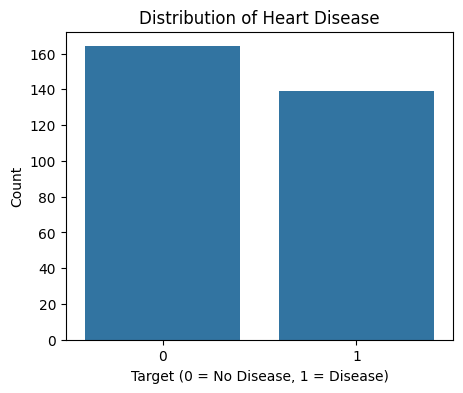

In [25]:
# Plot target distribution
plt.figure(figsize=(5,4))
sns.countplot(x=df['target'])
plt.title("Distribution of Heart Disease")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.savefig("target_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


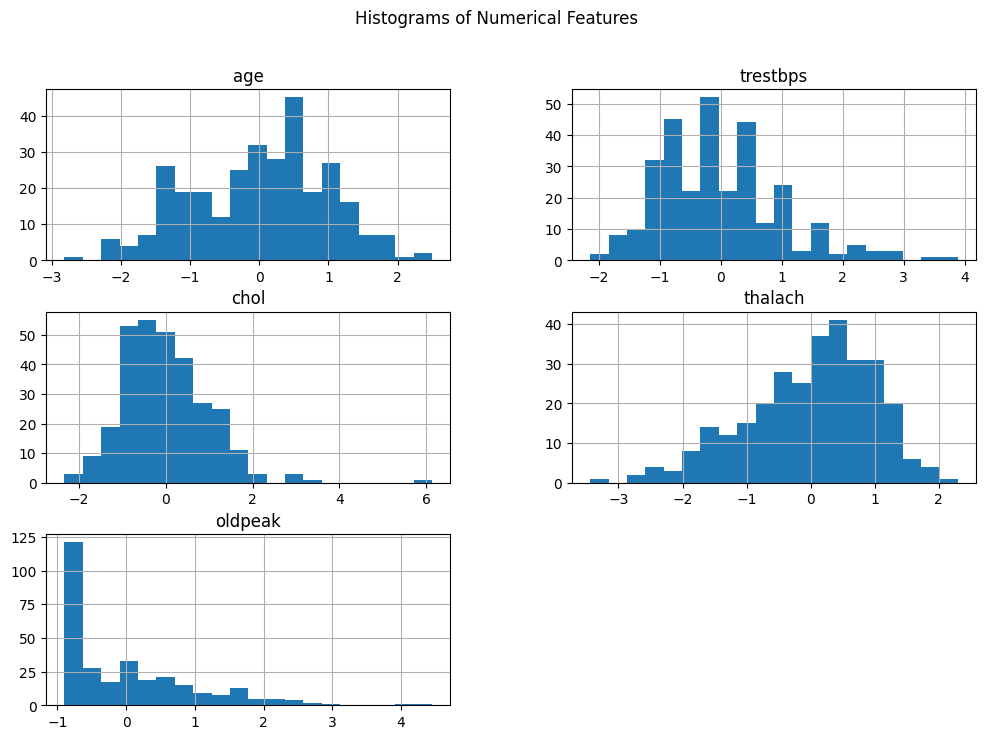

In [26]:
# Plot histograms for numerical variables
df[numerical_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Histograms of Numerical Features")
plt.savefig("histograms.png", dpi=300, bbox_inches="tight")

plt.show()


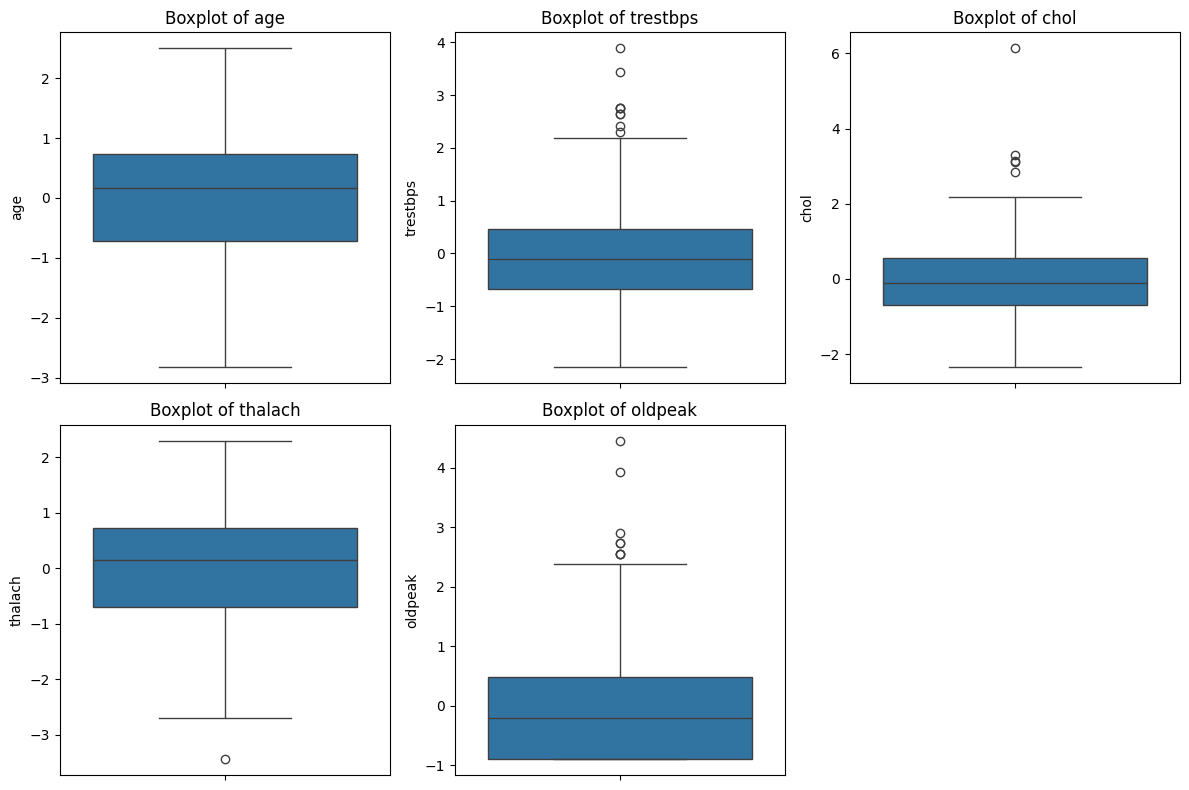

In [27]:
# Boxplots for numerical columns
plt.figure(figsize=(12,8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.savefig("boxplots.png", dpi=300, bbox_inches="tight")

plt.show()


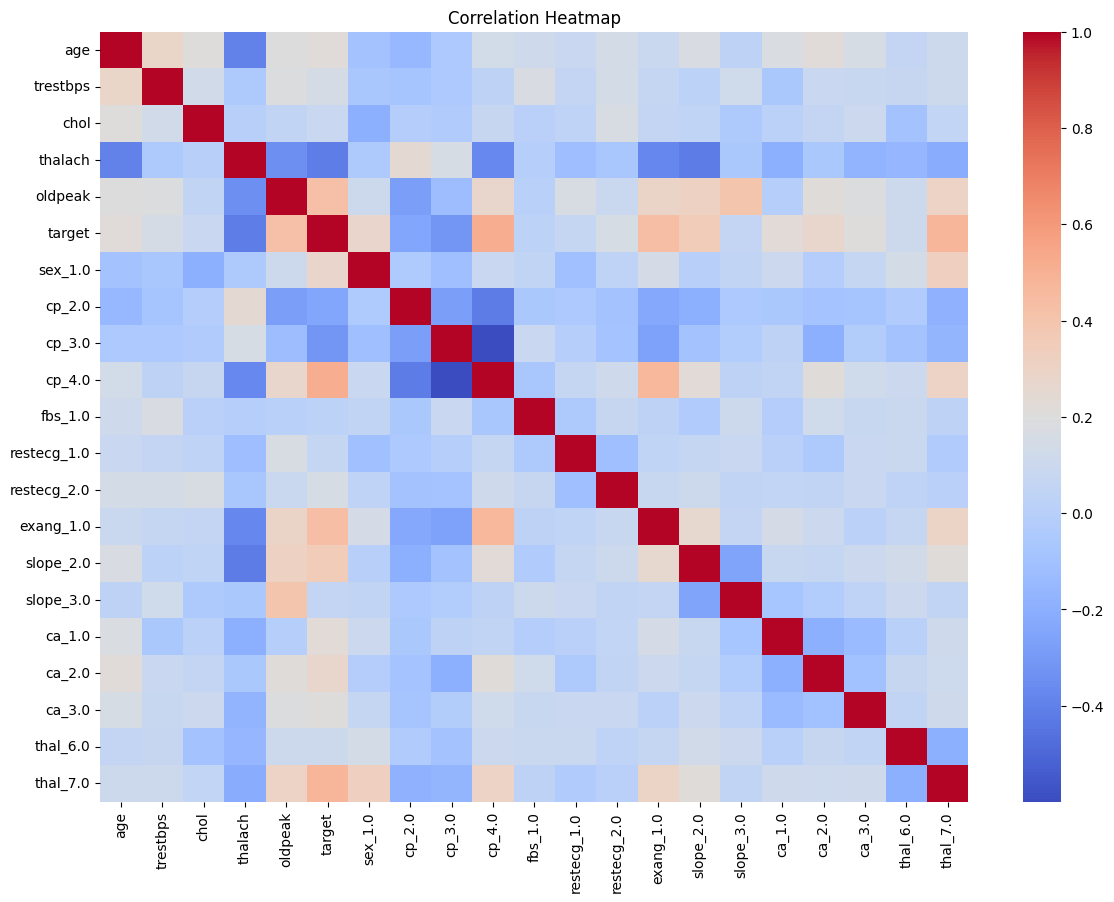

In [28]:
# Compute correlation matrix
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()


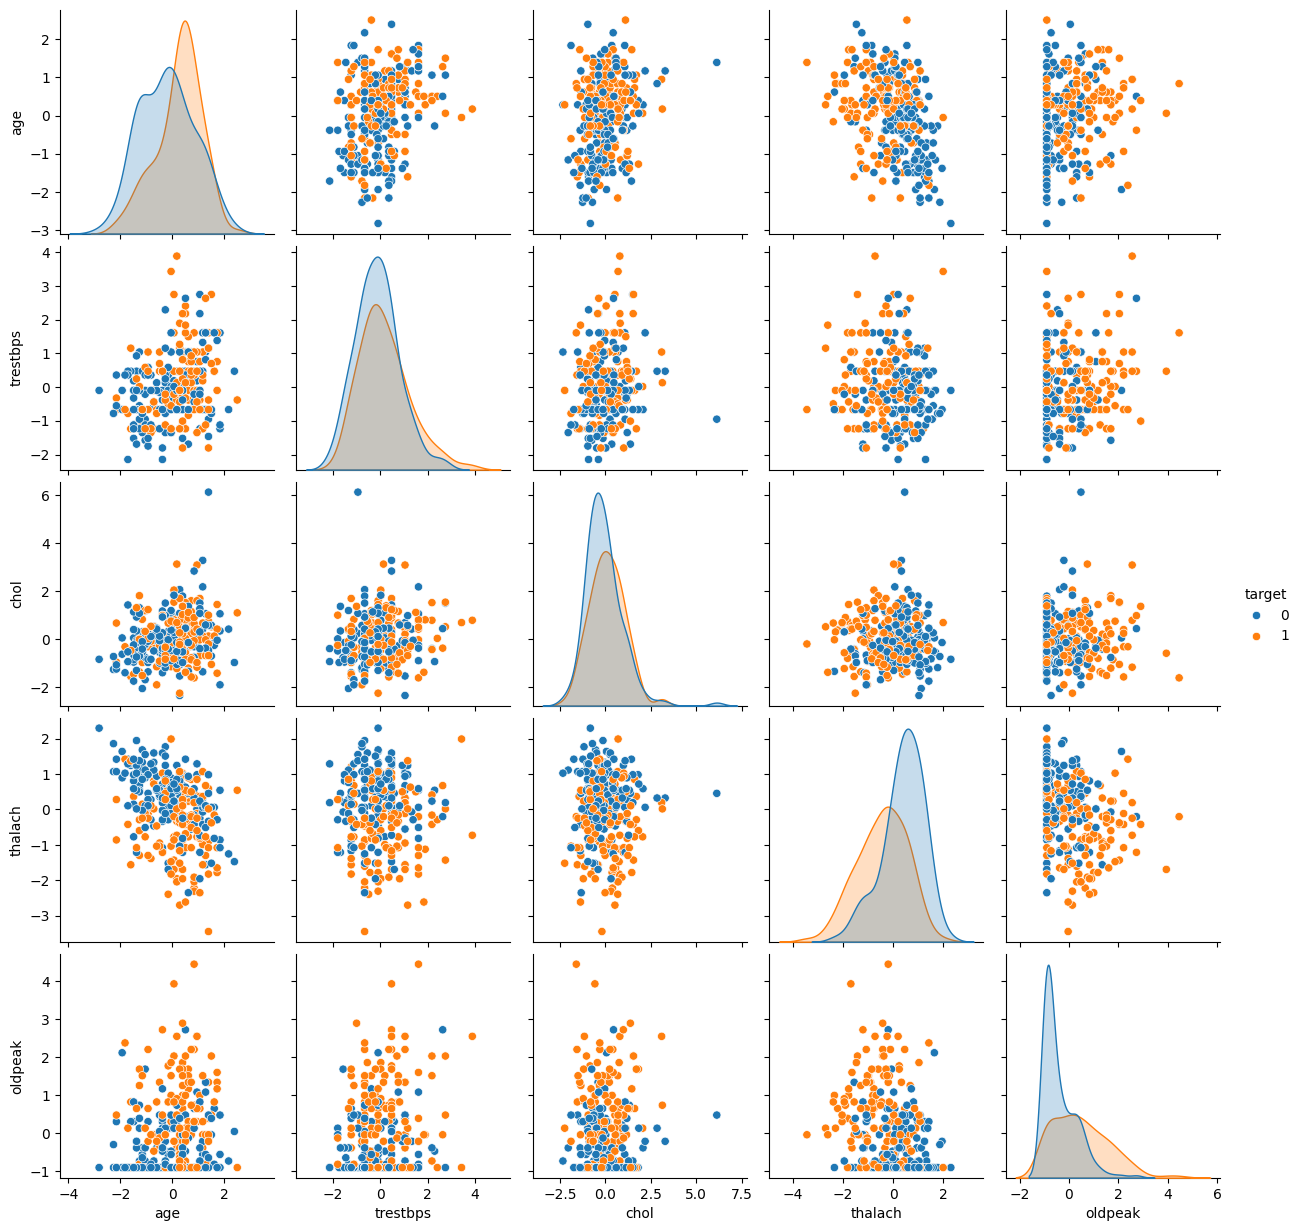

In [29]:
#  pairplot
sns.pairplot(df[numerical_cols + ['target']], hue="target")
plt.savefig("pairplot.png", dpi=300, bbox_inches="tight")

plt.show()


STEP 4 — Train/Test Split + Model Preparation

In [30]:
# Step 4.1: Separate input features and target
X = df.drop("target", axis=1)
y = df["target"]


In [31]:
from sklearn.model_selection import train_test_split

# Step 4.2: Split into train and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [32]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((242, 20), (61, 20), (242,), (61,))

In [33]:
#cross Validation
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

print("5-Fold Cross-Validation Accuracy:\n")

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model)
    ])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")


5-Fold Cross-Validation Accuracy:

KNN: 0.828 ± 0.023
Decision Tree: 0.716 ± 0.041
Random Forest: 0.802 ± 0.042
SVM: 0.825 ± 0.039


In [35]:
# Hyperparameter Tuning – KNN
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    knn_pipe,
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best KNN params:", knn_grid.best_params_)
print("Best KNN CV accuracy:", knn_grid.best_score_)

best_knn = knn_grid.best_estimator_


Best KNN params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'uniform'}
Best KNN CV accuracy: 0.8347789115646258


In [36]:
# Hyperparameter Tuning – Decision Tree
dt_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("dt", DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    "dt__max_depth": [3, 5, 7, 9, None],
    "dt__min_samples_split": [2, 5, 10],
    "dt__min_samples_leaf": [1, 2, 4],
    "dt__criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    dt_pipe,
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree params:", dt_grid.best_params_)
print("Best Decision Tree CV accuracy:", dt_grid.best_score_)

best_dt = dt_grid.best_estimator_


Best Decision Tree params: {'dt__criterion': 'entropy', 'dt__max_depth': 5, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 10}
Best Decision Tree CV accuracy: 0.7645408163265307


In [37]:
# Hyperparameter Tuning – Random Forest
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "rf__n_estimators": [50, 100, 200],
    "rf__max_depth": [None, 5, 10, 15],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best Random Forest CV accuracy:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_


Best Random Forest params: {'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Best Random Forest CV accuracy: 0.8098639455782312


In [46]:
# Hyperparameter Tuning – SVM
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

svm_param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf", "poly"],
    "svm__gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM params:", svm_grid.best_params_)
print("Best SVM CV accuracy:", svm_grid.best_score_)

best_svm = svm_grid.best_estimator_


Best SVM params: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best SVM CV accuracy: 0.8513605442176871


STEP 5 — Train Machine Learning Models

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [43]:
from sklearn.linear_model import LogisticRegression

# Train model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predict
y_pred_log = log_reg.predict(X_test)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))


Logistic Regression Accuracy: 0.8360655737704918

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61


Confusion Matrix:
 [[24  5]
 [ 5 27]]


In [41]:
from sklearn.neighbors import KNeighborsClassifier

# Train model
best_knn.fit(X_train, y_train)

# Predict
y_pred_knn = best_knn.predict(X_test)

# Evaluate
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


KNN Accuracy: 0.8688524590163934

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.93      0.87        29
           1       0.93      0.81      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


Confusion Matrix:
 [[27  2]
 [ 6 26]]


In [42]:
from sklearn.tree import DecisionTreeClassifier

# Train model
best_dt.fit(X_train, y_train)

# Predict
y_pred_dt = best_dt.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7377049180327869

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.86      0.76        29
           1       0.83      0.62      0.71        32

    accuracy                           0.74        61
   macro avg       0.75      0.74      0.74        61
weighted avg       0.76      0.74      0.73        61


Confusion Matrix:
 [[25  4]
 [12 20]]


In [44]:
from sklearn.ensemble import RandomForestClassifier

# Train model
best_rf.fit(X_train, y_train)

# Predict
y_pred_rf = best_rf.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.8524590163934426

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61


Confusion Matrix:
 [[26  3]
 [ 6 26]]


In [47]:
from sklearn.svm import SVC

# Train model
best_svm.fit(X_train, y_train)

# Predict
y_pred_svm = best_svm.predict(X_test)

# Evaluate
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


SVM Accuracy: 0.7868852459016393

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.79      0.78        29
           1       0.81      0.78      0.79        32

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61


Confusion Matrix:
 [[23  6]
 [ 7 25]]


STEP 6 — Model Evaluation & Comparison

In [48]:
# Collect model accuracies
model_names = ["Logistic Regression", "KNN", "Decision Tree", "Random Forest", "SVM"]
accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm)
]


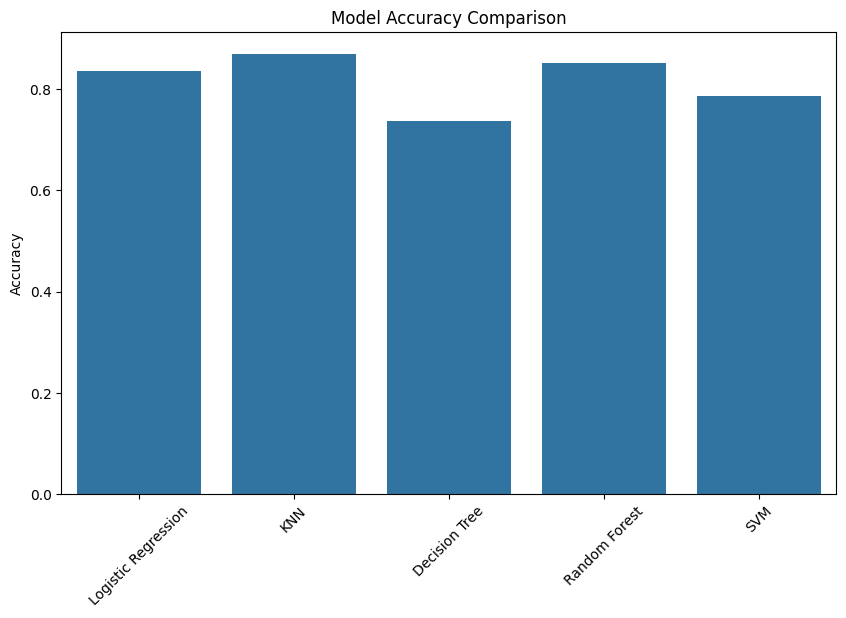

In [49]:
plt.figure(figsize=(10,6))
sns.barplot(x=model_names, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.savefig("Model Accuracy Comparison.png", dpi=300, bbox_inches="tight")
plt.show()


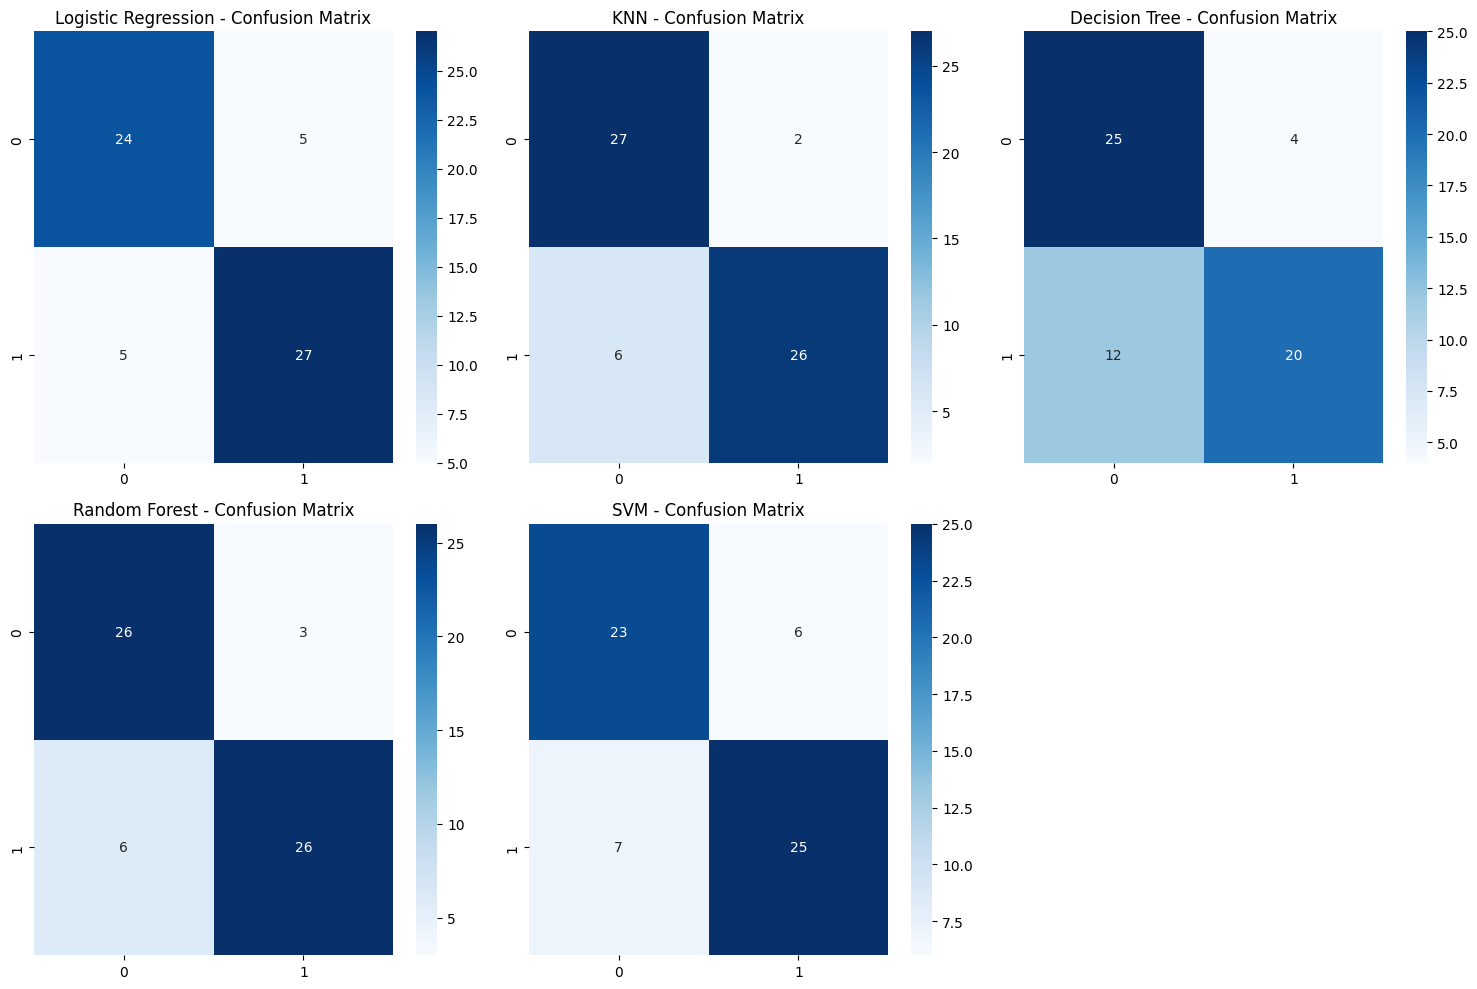

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": (log_reg, y_pred_log),
    "KNN": (best_knn, y_pred_knn),
    "Decision Tree": (best_dt, y_pred_dt),
    "Random Forest": (best_rf, y_pred_rf),
    "SVM": (best_svm, y_pred_svm)
}

plt.figure(figsize=(15,10))

for i, (name, (_, preds)) in enumerate(models.items(), 1):
    plt.subplot(2, 3, i)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()


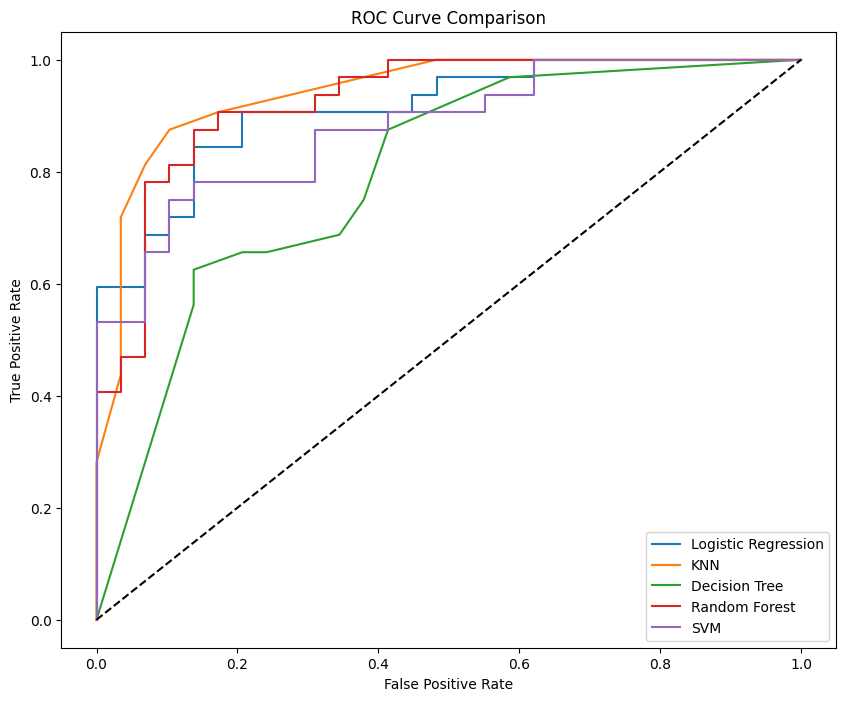

In [52]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,8))

# Logistic Regression
y_prob = log_reg.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="Logistic Regression")

# KNN
y_prob = best_knn.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="KNN")

# Decision Tree
y_prob = best_dt.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="Decision Tree")

# Random Forest
y_prob = best_rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="Random Forest")

# SVM (requires probability=True)
y_prob = best_svm.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="SVM")

plt.plot([0,1], [0,1], "k--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()


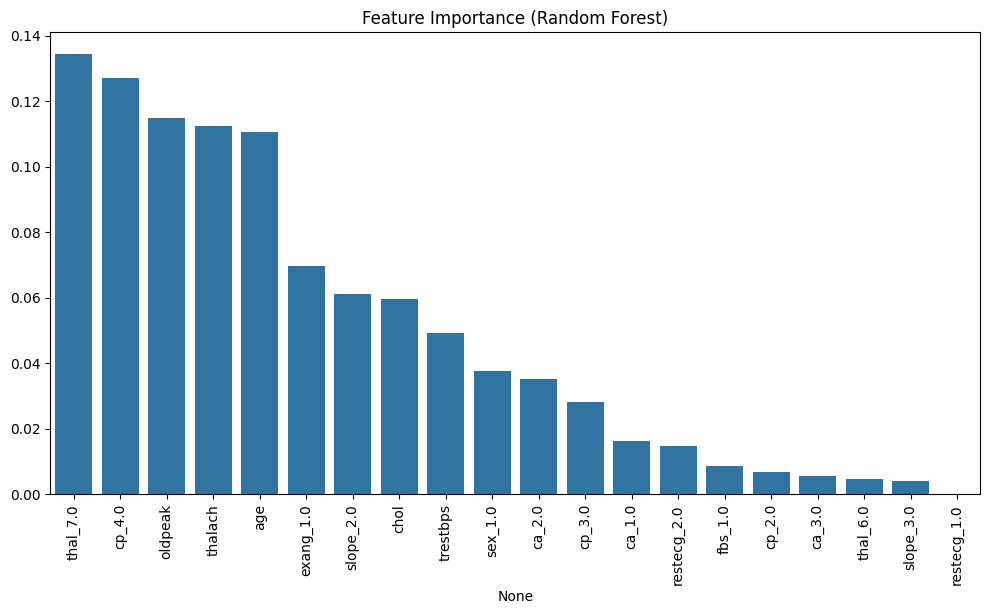

In [55]:
import numpy as np

# Extract feature importances
rf_model = best_rf.named_steps["rf"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
sns.barplot(x=X.columns[indices], y=importances[indices])
plt.title("Feature Importance (Random Forest)")
plt.xticks(rotation=90)
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


In [56]:
results = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

results


,Model,Accuracy
0,Logistic Regression,0.836066
1,KNN,0.868852
2,Decision Tree,0.737705
3,Random Forest,0.852459
4,SVM,0.786885
